# Little project : Counting lines

In this little project, we are going to build a dataset of 28x28 pixel images with straight lines drawn randomly. The number of lines in each image will be chosen randomly as an integer between 1 and 10.

The goal of the neural network is to give as output a vector of 10 components in which the i-th component of that vector is the probability that the image received as input has i lines according to the network.

## Importations

In [ ]:
# To build the dataset
import numpy as np
import matplotlib.pyplot as plt
import random
import sys
from tensorflow import keras
from keras.utils import to_categorical

# To create the models
from keras import models
from keras import layers
import tensorflow as tf
import time

## Dataset

As explained before, we are going to build a dataset containing images in which several lines are drawn.

The first idea is to be able to generate one image with a certain number of lines, drawn randomly.

To do so, we are going to generate a random slope and a random intercept. With those 2 numbers, we will then put this line in a square of 28x28, with the coordinate (0,0) in the middle of the image.

### Image generation

In [ ]:
def generate_image(nb_line):
  # Input :
  ##    - nb_line : int - number of lines to draw
  # Output :
  ##    - img : array numpy - the image created

  # We initialize the output matrix
  img = np.zeros((28,28))
  img = img.astype(int)
  # We initialize the x-axis coordinates of the line
  x = np.linspace(-14,13,28,endpoint=True)

  # For each desired line
  for i in range(nb_line):
    # Random slope
    a = np.random.randint(-5,6,dtype=int)
    # Random intercept
    b = np.random.randint(-14,14,dtype=int)
    # We create the line
    y = a*x+b

    # We aggregate the x-axis/y-axis
    tab = np.vstack((x,y))
    # We only keep the points that are on the image
    mask=(tab[1]>=-14)&(tab[1]<=13)
    tab_in_img = tab[:,mask]
    # We re-scale to the index of the numpy array
    tab_in_img[0,:] = tab_in_img[0,:] + 14
    tab_in_img[1,:] = tab_in_img[1,:] + 14
    tab_in_img = tab_in_img.astype(int)

    # We add the line to the image
    img[tab_in_img[1,:],tab_in_img[0,:]] = img[tab_in_img[1,:],tab_in_img[0,:]]*0 + 1

  return img

Once this function is created, we can try to create few images, with different numbers of lines.

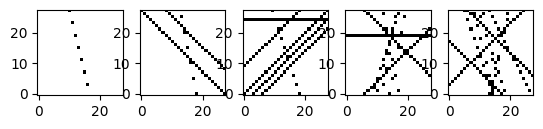

In [ ]:
# Test of the function
plt.subplot(1,5,1)
plt.imshow(generate_image(1),cmap=plt.cm.binary, origin='lower')
plt.subplot(1,5,2)
plt.imshow(generate_image(3),cmap=plt.cm.binary, origin='lower')
plt.subplot(1,5,3)
plt.imshow(generate_image(6),cmap=plt.cm.binary, origin='lower')
plt.subplot(1,5,4)
plt.imshow(generate_image(8),cmap=plt.cm.binary, origin='lower')
plt.subplot(1,5,5)
plt.imshow(generate_image(10),cmap=plt.cm.binary, origin='lower')

As we can see, we are building images with a certain number of lines, as wanted. But, we can see that the lines are built with points that can be distant form each other. This observation makes difficult to distinguish each line when they are numerous.

We can then create a new function, which will add intermediate points, to obtain better defined lines.

In [ ]:
def add_inter_points(tab,a):
  # Inputs :
  ##    - tab : array numpy - indexes of the line
  ##    - a   : int - the slope of the line
  # Output :
  ##    - new_tab : array numpy - new indexes of the line

  # We initialize the result array
  new_tab = [[],[]]

  # For each index of the line
  for i in range(len(tab[0])-1):
    # We add this index to the new indexes array
    new_tab[0].append(tab[0,i])
    new_tab[1].append(tab[1,i])

    # And we generate a portion of line to reach the next index
    for k in range(abs(a)-1):
      new_tab[0].append(tab[0,i])
      #new_tab[1].append(tab[1,i]+(k+1)*(-1)^(a<0))
      if a > 0:
        # In the case of
        new_tab[1].append(tab[1,i]+k+1)
      else:
        new_tab[1].append(tab[1,i]-k-1)

  # We convert the array into a numpy array
  new_tab = np.array(new_tab)
  return new_tab

We can now redefine the previous function, to add those intermediate points.

In [ ]:
def generate_image_update(nb_line):
  # Input :
  ##    - nb_line : int - number of lines to draw
  # Output :
  ##    - img : array numpy - the image created

  # We initialize the output matrix
  img = np.zeros((28,28))
  img = img.astype(int)
  # We initialize the x-axis coordinates of the line
  x = np.linspace(-14,13,28,endpoint=True)

  # For each desired line
  for i in range(nb_line):
    # Random slope
    a = np.random.randint(-5,6,dtype=int)
    # Random intercept
    b = np.random.randint(-14,14,dtype=int)
    # We create the line
    y = a*x+b

    # We aggregate the x-axis/y-axis
    tab = np.vstack((x,y))
    # We only keep the points that are on the image
    mask=(tab[1]>=-14)&(tab[1]<=13)
    tab_in_img = tab[:,mask]
    # We re-scale to the index of the numpy array
    tab_in_img[0,:] = tab_in_img[0,:] + 14
    tab_in_img[1,:] = tab_in_img[1,:] + 14
    tab_in_img = tab_in_img.astype(int)
    # We add the intermediate points
    tab_in_img = add_inter_points(tab_in_img,a)

    # We add the line to the image
    img[tab_in_img[1,:],tab_in_img[0,:]] = img[tab_in_img[1,:],tab_in_img[0,:]]*0 + 1

  return img

And as we've done before, we can test the new function, by plotting few examples...

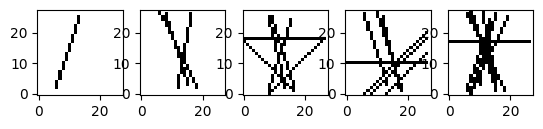

In [ ]:
# Test of the function
plt.subplot(1,5,1)
plt.imshow(generate_image_update(1),cmap=plt.cm.binary, origin='lower')
plt.subplot(1,5,2)
plt.imshow(generate_image_update(3),cmap=plt.cm.binary, origin='lower')
plt.subplot(1,5,3)
plt.imshow(generate_image_update(6),cmap=plt.cm.binary, origin='lower')
plt.subplot(1,5,4)
plt.imshow(generate_image_update(8),cmap=plt.cm.binary, origin='lower')
plt.subplot(1,5,5)
plt.imshow(generate_image_update(10),cmap=plt.cm.binary, origin='lower')

As we can see, the lines are better defined, and it seems easier to distinguish them among others.

### Dataset generation

Now, we are going to create our dataset, using the previous function. This dataset will be uniform (same number of images for each number of lines).

Then, the following function needs only one parameter : the number of lines in each group (the global dataset will have 10 times more images).

In [ ]:
def generate_dataset(nb_images):
  # Input :
  ##   - nb_images : int - number of images in each group
  # Outputs :
  ##   - data   : array - the images
  ##   - labels : array - the corresponding labels

  # We initialize the arrays
  data = []
  labels = []
  # Printing the evolution
  print("Creation of the dataset...")
  sys.stdout.write("\r" + str(0) + "/" + str(10*nb_images) + " [" + 10*"..." + "]")
  sys.stdout.flush()

  # For each line-group we create the images
  for n in range(1,11):
    for k in range(nb_images):
      data.append(generate_image_update(n))
      labels.append(n)
      # Printing the evolution
    sys.stdout.write("\r" + str(n*nb_images) + "/" + str(10*nb_images) + " [" + "==="*n + (10-n)*"..." + "]")
    sys.stdout.flush()
  # Printing the evolution
  print("\n")
  print("Dataset successfully created")

  # We shuffle the data
  dataset = list(zip(data,labels))
  random.shuffle(dataset)

  data, labels = zip(*dataset)

  return data,labels

For our case, we are going to build a dataset of size 100 000 images (80 000 for the training and 20 000 for the validation).

In [ ]:
# Generation of our dataset
data, labels = generate_dataset(10000)

Creation of the dataset...
100000/100000 [==============================]

Dataset successfully created


To make sure that everything went weel, we can then show the first 10 images generated. In particular, with this little check, we will see if the dataset has been well shuffled.

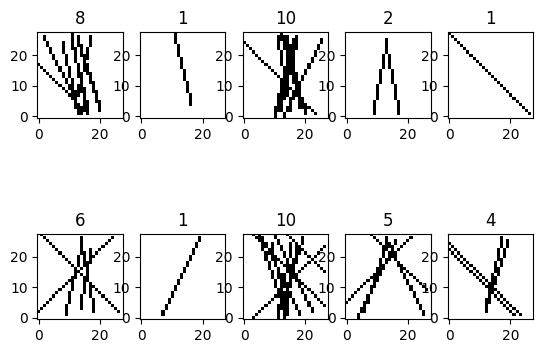

In [ ]:
# Let's show a couple of images
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(data[i],cmap=plt.cm.binary, origin='lower')
  plt.title(labels[i])

To end this data generation, we are going to separate the Training/Validation sets.

In [ ]:
data = np.array(data)
# Train and Validation datasets
train_images = data[0:80000]
valid_images = data[80000:]

# Train and Validation labels
labels = np.array(labels)
train_labels = labels[0:80000]
valid_labels = labels[80000:]
# We convert them into categorical variables
train_labels = to_categorical(train_labels)
valid_labels = to_categorical(valid_labels)

print("Shapes : ")
print("  - train dataset :", train_images.shape)
print("  - train labels :", train_labels.shape)
print("  - validation dataset :", valid_images.shape)
print("  - validation labels :", valid_labels.shape)

Shapes : 
  - train dataset : (80000, 28, 28)
  - train labels : (80000, 11)
  - validation dataset : (20000, 28, 28)
  - validation labels : (20000, 11)


## First model : simple MLP


### Creation of the model

For this first model, we are going to apply a really simple fully connected neural MLP network. Here, we will use only 2 hidden layers, and an output layer, to obtain the 11-dimensional result (0 lines is considered as a class also).

In [ ]:
# We flatten the images
train_images = train_images.reshape((80000, 28 * 28))
valid_images = valid_images.reshape((20000, 28 * 28))

In [ ]:
# Creation of the model
network_MLP = models.Sequential()
network_MLP.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network_MLP.add(layers.Dense(512, activation='relu', input_shape=(512,)))
network_MLP.add(layers.Dense(11, activation='softmax'))

network_MLP.summary()

callbacks = [keras.callbacks.ModelCheckpoint("best_model",save_best_only=True)]

# Compile : we choose ADAM optimizer, with the categorical cross entropy loss (softmax + cros enntropy loss)
network_MLP.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               401920    
                                                                 
 dense_1 (Dense)             (None, 512)               262656    
                                                                 
 dense_2 (Dense)             (None, 11)                5643      
                                                                 
Total params: 670219 (2.56 MB)
Trainable params: 670219 (2.56 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Training
t = time.time()
history = network_MLP.fit(train_images, train_labels, epochs=20, validation_data=(valid_images, valid_labels), batch_size=128,callbacks=callbacks)
t_MLP_simple = time.time() - t
print("Training time : ", t_MLP_simple)

Epoch 1/20
625/625 [==============================] - 12s 19ms/step - loss: 0.8589 - accuracy: 0.6347 - val_loss: 0.6493 - val_accuracy: 0.7098
Epoch 2/20
625/625 [==============================] - 11s 18ms/step - loss: 0.5547 - accuracy: 0.7627 - val_loss: 0.5787 - val_accuracy: 0.7530
Epoch 3/20
625/625 [==============================] - 10s 15ms/step - loss: 0.4710 - accuracy: 0.8042 - val_loss: 0.5630 - val_accuracy: 0.7723
Epoch 4/20
625/625 [==============================] - 11s 18ms/step - loss: 0.3971 - accuracy: 0.8391 - val_loss: 0.6024 - val_accuracy: 0.7632
Epoch 5/20
625/625 [==============================] - 11s 17ms/step - loss: 0.3495 - accuracy: 0.8598 - val_loss: 0.6304 - val_accuracy: 0.7596
Epoch 6/20
625/625 [==============================] - 12s 18ms/step - loss: 0.2964 - accuracy: 0.8827 - val_loss: 0.6736 - val_accuracy: 0.7612
Epoch 7/20
625/625 [==============================] - 10s 17ms/step - loss: 0.2640 - accuracy: 0.8961 - val_loss: 0.6945 - val_accuracy:

### Results

To evaluate the quality of the model, we can look at the evolution of the loss function and the accuracy on the train images. Then, we can apply the model on the validation set, to see if the model is well accurate.

In [ ]:
# Historical losses and accuracies
train_loss = history.history['loss']
train_acc = history.history['accuracy']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

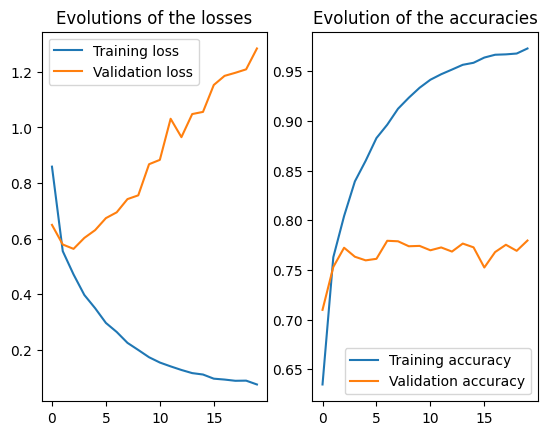

In [ ]:
# Plot the evolutions
plt.subplot(1,2,1)
plt.plot(train_loss, label="Training loss")
plt.plot(val_loss, label="Validation loss")
plt.title("Evolutions of the losses")
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_acc, label="Training accuracy")
plt.plot(val_acc, label="Validation accuracy")
plt.title("Evolution of the accuracies")
plt.legend()

# Results on the validation set
#print("VALIDATION LOSS : ", valid_loss)
#print("VALIDATION ACCURACY : ", valid_acc)

In [ ]:
# We take the best model obtained among all the epochs
best_model = keras.models.load_model("best_model")
# We apply it on the validation dataset
valid_loss, valid_acc = best_model.evaluate(valid_images, valid_labels)
print("VALIDATION LOSS : ", valid_loss)
print("VALIDATION ACCURACY : ", valid_acc)

625/625 [==============================] - 2s 3ms/step - loss: 0.5630 - accuracy: 0.7723
VALIDATION LOSS :  0.5630329847335815
VALIDATION ACCURACY :  0.7723000049591064


As we can see, the results are quite good : we have reached an accuracy of around 0.76 on the validation set, which is quite good. The problem is that we can clearly see that we have overfitted the data. In fact, the training loss is decreasing a lot, while after a certain number of epochs, the validation loss is increasing.

### Dropout

To try to limit this overfitting, we can try to add dropout to the model. That way, we will obtain a model more able to generalize, which is less focusing on only few parts of the input.

In [ ]:
# Creation of the model
network_MLP = models.Sequential()
network_MLP.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network_MLP.add(layers.Dropout(0.2))
network_MLP.add(layers.Dense(512, activation='relu'))
network_MLP.add(layers.Dropout(0.2))
network_MLP.add(layers.Dense(512, activation='relu'))
network_MLP.add(layers.Dropout(0.2))
network_MLP.add(layers.Dense(512, activation='relu'))

network_MLP.add(layers.Dense(11, activation='softmax'))

network_MLP.summary()

callbacks = [keras.callbacks.ModelCheckpoint("best_model",save_best_only=True)]

# Compile : we choose ADAM optimizer, with the categorical cross entropy loss (softmax + cros enntropy loss)
network_MLP.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 512)               401920    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_4 (Dense)             (None, 512)               262656    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_5 (Dense)             (None, 512)               262656    
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 dense_6 (Dense)             (None, 512)              

In [ ]:
# Training
t = time.time()
history = network_MLP.fit(train_images, train_labels, epochs=20, validation_data=(valid_images, valid_labels), batch_size=128,callbacks=callbacks)
t_MLP_dropout = time.time() - t
print("Training time : ", t_MLP_dropout)

Epoch 1/20
625/625 [==============================] - 22s 33ms/step - loss: 0.9914 - accuracy: 0.5676 - val_loss: 0.6703 - val_accuracy: 0.7093
Epoch 2/20
625/625 [==============================] - 20s 32ms/step - loss: 0.7268 - accuracy: 0.6804 - val_loss: 0.6677 - val_accuracy: 0.7229
Epoch 3/20
625/625 [==============================] - 20s 32ms/step - loss: 0.6456 - accuracy: 0.7201 - val_loss: 0.6182 - val_accuracy: 0.7247
Epoch 4/20
625/625 [==============================] - 20s 33ms/step - loss: 0.5875 - accuracy: 0.7466 - val_loss: 0.5589 - val_accuracy: 0.7674
Epoch 5/20
625/625 [==============================] - 21s 34ms/step - loss: 0.5507 - accuracy: 0.7650 - val_loss: 0.5302 - val_accuracy: 0.7747
Epoch 6/20
625/625 [==============================] - 20s 32ms/step - loss: 0.5256 - accuracy: 0.7761 - val_loss: 0.5369 - val_accuracy: 0.7792
Epoch 7/20
625/625 [==============================] - 21s 34ms/step - loss: 0.4952 - accuracy: 0.7911 - val_loss: 0.5387 - val_accuracy:

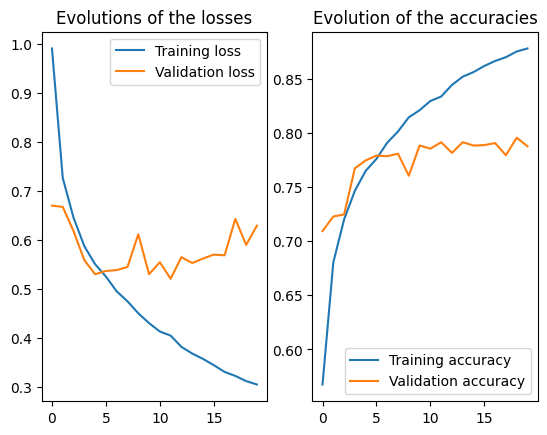

In [ ]:
# Historical losses and accuracies
train_loss = history.history['loss']
train_acc = history.history['accuracy']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

# Plot the evolutions
plt.subplot(1,2,1)
plt.plot(train_loss, label="Training loss")
plt.plot(val_loss, label="Validation loss")
plt.title("Evolutions of the losses")
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_acc, label="Training accuracy")
plt.plot(val_acc, label="Validation accuracy")
plt.title("Evolution of the accuracies")
plt.legend()

In [ ]:
# We take the best model obtained among all the epochs
best_model = keras.models.load_model("best_model")
# We apply it on the validation dataset
valid_loss, valid_acc = best_model.evaluate(valid_images, valid_labels)
print("VALIDATION LOSS : ", valid_loss)
print("VALIDATION ACCURACY : ", valid_acc)

625/625 [==============================] - 2s 4ms/step - loss: 0.5209 - accuracy: 0.7915
VALIDATION LOSS :  0.5208944082260132
VALIDATION ACCURACY :  0.7914999723434448


Now, let's create some images, with a certain number of lines, and apply the model on them, to see which result we obtain.

1/1 [==============================] - 0s 33ms/step


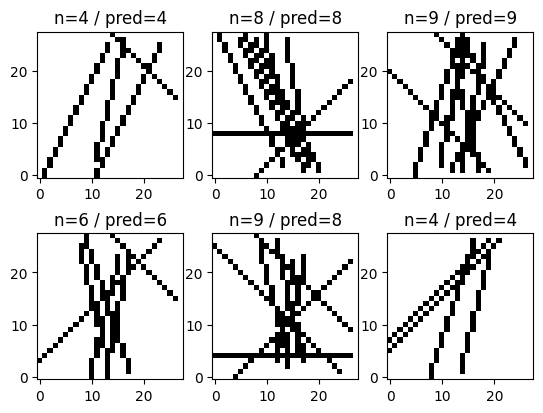

In [ ]:
for i in range(6):
  nb_lines = np.random.randint(1,11,dtype=int)
  image = generate_image_update(nb_lines)
  image_flatten = image.reshape((1, 28 * 28))

  prediction = np.argmax(best_model.predict(image_flatten))

  plt.subplot(2,3,i+1)
  plt.imshow(image,cmap=plt.cm.binary, origin='lower')
  plt.title("n=" + str(nb_lines) + " / pred=" + str(prediction))

As we can see, in most of the cases, the response value is the right one. Nevertheless, in some cases, the result can be a bit different (one or two wrong predictions).

## Second model : Convolutional network

First, we have to change the shape of the input. In fact, here, we do not need to flatten the data : we use its initial form (28x28 matrix).

In [ ]:
train_images_CONV = train_images.reshape((80000, 28, 28, 1))
valid_images_CONV = valid_images.reshape((20000, 28, 28, 1))

Then, we can create a convolutional network. Here, we will first try to implement a network filled with 3x3 filters, and only 3 layers.

After this convolutional part, we will flatten the ourtput activation map, and apply MLP structure on it, with only one hidden layer

In [ ]:
# Convolutional layers
model_CONV = models.Sequential()                                                      # Size : b, 28, 28, 1

model_CONV.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))) # Size : b, 26, 26, 32
model_CONV.add(layers.MaxPooling2D((2, 2)))                                           # Size : b, 13, 13, 32

model_CONV.add(layers.Conv2D(64, (3, 3), activation='relu'))                          # Size : b, 11, 11, 64
model_CONV.add(layers.MaxPooling2D((2, 2)))                                           # Size : b,  5,  5, 64

model_CONV.add(layers.Conv2D(64, (3, 3), activation='relu'))                          # Size : b,  3,  3, 64

# MLP layers
model_CONV.add(layers.Flatten())                                                      # Size : b, 3x3x64
model_CONV.add(layers.Dense(128, activation='relu'))                                  # Size : b, 128
model_CONV.add(layers.Dense(11, activation='softmax'))                                # Size : b, 11

# Summary
model_CONV.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 576)              

In [ ]:
callbacks_CONV = [keras.callbacks.ModelCheckpoint("best_model_CONV",save_best_only=True)]

model_CONV.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

t = time.time()
history_CONV = model_CONV.fit(train_images_CONV, train_labels, epochs=10, batch_size=64, validation_data=(valid_images_CONV, valid_labels), callbacks=callbacks_CONV)
t_CONV_3 = time.time() - t
print("Training time : ", t_CONV_3)

Epoch 1/10
1250/1250 [==============================] - 64s 51ms/step - loss: 0.7619 - accuracy: 0.6794 - val_loss: 0.5728 - val_accuracy: 0.7530
Epoch 2/10
1250/1250 [==============================] - 64s 51ms/step - loss: 0.5705 - accuracy: 0.7719 - val_loss: 0.5194 - val_accuracy: 0.7914
Epoch 3/10
1250/1250 [==============================] - 65s 52ms/step - loss: 0.5268 - accuracy: 0.7955 - val_loss: 0.4762 - val_accuracy: 0.8160
Epoch 4/10
1250/1250 [==============================] - 62s 49ms/step - loss: 0.5070 - accuracy: 0.8041 - val_loss: 0.4807 - val_accuracy: 0.8137
Epoch 5/10
1250/1250 [==============================] - 64s 51ms/step - loss: 0.4866 - accuracy: 0.8137 - val_loss: 0.4957 - val_accuracy: 0.7952
Epoch 6/10
1250/1250 [==============================] - 67s 54ms/step - loss: 0.4723 - accuracy: 0.8209 - val_loss: 0.4606 - val_accuracy: 0.8280
Epoch 7/10
1250/1250 [==============================] - 62s 50ms/step - loss: 0.4598 - accuracy: 0.8258 - val_loss: 0.4806 -

In [ ]:
# Historical losses and accuracies
train_loss_CONV = history_CONV.history['loss']
train_acc_CONV = history_CONV.history['accuracy']

val_acc_CONV = history_CONV.history['val_accuracy']
val_loss_CONV = history_CONV.history['val_loss']

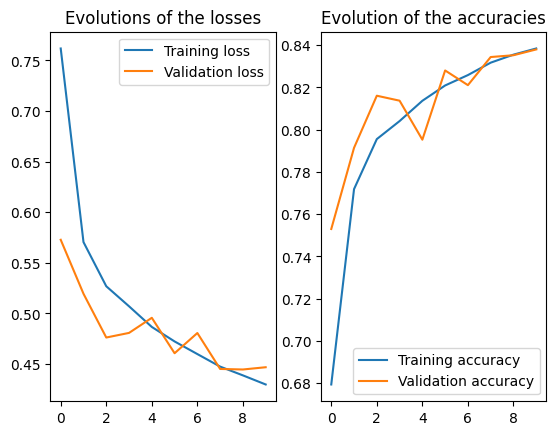

In [ ]:
# Plot the evolutions
plt.subplot(1,2,1)
plt.plot(train_loss_CONV, label="Training loss")
plt.plot(val_loss_CONV, label="Validation loss")
plt.title("Evolutions of the losses")
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_acc_CONV, label="Training accuracy")
plt.plot(val_acc_CONV, label="Validation accuracy")
plt.title("Evolution of the accuracies")
plt.legend()

In [ ]:
# We take the best model obtained among all the epochs
best_model_CONV = keras.models.load_model("best_model_CONV")
# We apply it on the validation dataset
valid_loss, valid_acc = best_model_CONV.evaluate(valid_images_CONV, valid_labels)
print("VALIDATION LOSS : ", valid_loss)
print("VALIDATION ACCURACY : ", valid_acc)

625/625 [==============================] - 5s 8ms/step - loss: 0.4446 - accuracy: 0.8352
VALIDATION LOSS :  0.4445679187774658
VALIDATION ACCURACY :  0.8352000117301941


1/1 [==============================] - 0s 19ms/step


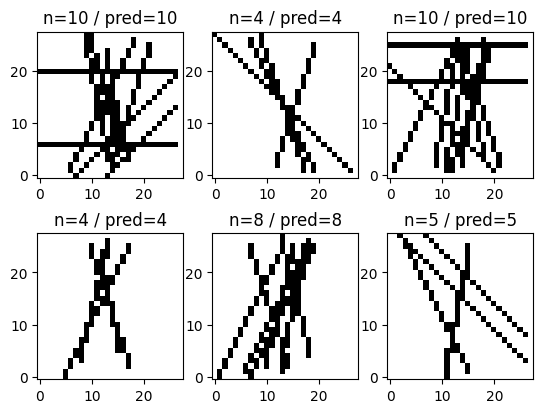

In [ ]:
for i in range(6):
  nb_lines = np.random.randint(1,11,dtype=int)
  image = generate_image_update(nb_lines)
  image_CONV = image.reshape((1, 28, 28))

  prediction = np.argmax(model_CONV.predict(image_CONV))

  plt.subplot(2,3,i+1)
  plt.imshow(image,cmap=plt.cm.binary, origin='lower')
  plt.title("n=" + str(nb_lines) + " / pred=" + str(prediction))

## Third model : Improve the best model

In [ ]:
# Convolutional layers
model_CONV = models.Sequential()                                                      # Size : b, 28, 28, 1

model_CONV.add(layers.Conv2D(64, (5, 5), activation='relu', input_shape=(28, 28, 1))) # Size : b, 24, 24, 64
model_CONV.add(layers.MaxPooling2D((2, 2)))                                           # Size : b, 12, 12, 64

model_CONV.add(layers.Conv2D(10, (1,1), activation='relu'))                           # Size : b, 12, 12, 10
model_CONV.add(layers.Conv2D(64, (5, 5), activation='relu', padding='same'))          # Size : b, 12, 12, 64
model_CONV.add(layers.MaxPooling2D((2, 2)))                                           # Size : b,  6,  6, 64

model_CONV.add(layers.Conv2D(10, (1,1), activation='relu'))                           # Size : b,  6,  6, 10
model_CONV.add(layers.Conv2D(64, (5, 5), activation='relu'))                          # Size : b,  2,  2, 64

# MLP layers
model_CONV.add(layers.Flatten())                                                      # Size : b, 2x2x64
model_CONV.add(layers.Dense(128, activation='relu'))                                  # Size : b, 128
model_CONV.add(layers.Dense(11, activation='softmax'))                                # Size : b, 11

# Summary
model_CONV.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 24, 24, 64)        1664      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 12, 12, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 12, 12, 10)        650       
                                                                 
 conv2d_5 (Conv2D)           (None, 12, 12, 64)        16064     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 6, 6, 10)         

In [ ]:
callbacks_CONV = [keras.callbacks.ModelCheckpoint("best_model_CONV",save_best_only=True)]

model_CONV.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

t = time.time()
history_CONV = model_CONV.fit(train_images_CONV, train_labels, epochs=10, batch_size=64, validation_data=(valid_images_CONV, valid_labels), callbacks=callbacks_CONV)
t_CONV_5 = time.time() - t

Epoch 1/10
1250/1250 [==============================] - 93s 73ms/step - loss: 0.6671 - accuracy: 0.7212 - val_loss: 0.5439 - val_accuracy: 0.7965
Epoch 2/10
1250/1250 [==============================] - 93s 74ms/step - loss: 0.4804 - accuracy: 0.8089 - val_loss: 0.4749 - val_accuracy: 0.8184
Epoch 3/10
1250/1250 [==============================] - 90s 72ms/step - loss: 0.4463 - accuracy: 0.8236 - val_loss: 0.4052 - val_accuracy: 0.8447
Epoch 4/10
1250/1250 [==============================] - 90s 72ms/step - loss: 0.4147 - accuracy: 0.8381 - val_loss: 0.4194 - val_accuracy: 0.8430
Epoch 5/10
1250/1250 [==============================] - 97s 78ms/step - loss: 0.4059 - accuracy: 0.8435 - val_loss: 0.3936 - val_accuracy: 0.8449
Epoch 6/10
1250/1250 [==============================] - 90s 72ms/step - loss: 0.3936 - accuracy: 0.8484 - val_loss: 0.3994 - val_accuracy: 0.8489
Epoch 7/10
1250/1250 [==============================] - 90s 72ms/step - loss: 0.3845 - accuracy: 0.8524 - val_loss: 0.4043 -

In [ ]:
# Historical losses and accuracies
train_loss_CONV = history_CONV.history['loss']
train_acc_CONV = history_CONV.history['accuracy']

val_acc_CONV = history_CONV.history['val_accuracy']
val_loss_CONV = history_CONV.history['val_loss']

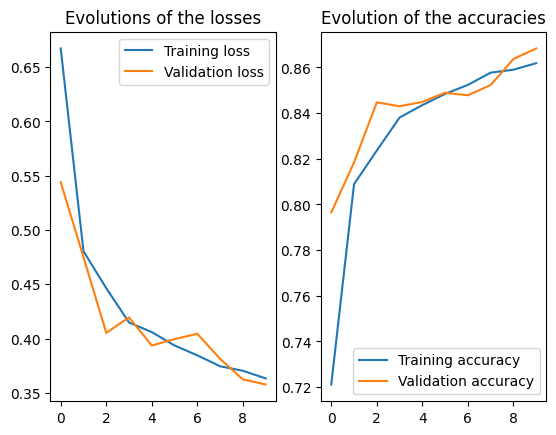

In [ ]:
# Plot the evolutions
plt.subplot(1,2,1)
plt.plot(train_loss_CONV, label="Training loss")
plt.plot(val_loss_CONV, label="Validation loss")
plt.title("Evolutions of the losses")
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_acc_CONV, label="Training accuracy")
plt.plot(val_acc_CONV, label="Validation accuracy")
plt.title("Evolution of the accuracies")
plt.legend()

In [ ]:
# We take the best model obtained among all the epochs
best_model_CONV = keras.models.load_model("best_model_CONV")
# We apply it on the validation dataset
valid_loss, valid_acc = best_model_CONV.evaluate(valid_images_CONV, valid_labels)
print("VALIDATION LOSS : ", valid_loss)
print("VALIDATION ACCURACY : ", valid_acc)

625/625 [==============================] - 7s 11ms/step - loss: 0.3577 - accuracy: 0.8683
VALIDATION LOSS :  0.35765543580055237
VALIDATION ACCURACY :  0.8683000206947327


1/1 [==============================] - 0s 26ms/step


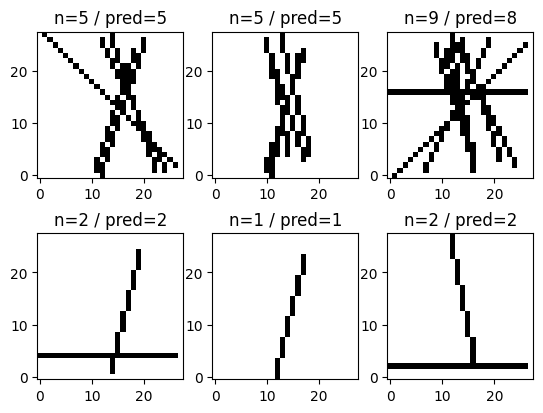

In [ ]:
for i in range(6):
  nb_lines = np.random.randint(1,11,dtype=int)
  image = generate_image_update(nb_lines)
  image_CONV = image.reshape((1, 28, 28))

  prediction = np.argmax(model_CONV.predict(image_CONV))

  plt.subplot(2,3,i+1)
  plt.imshow(image,cmap=plt.cm.binary, origin='lower')
  plt.title("n=" + str(nb_lines) + " / pred=" + str(prediction))